# Introduction
### This project analyzes housing data to understand the factors influencing house prices and applies machine learning techniques to both predict prices and segment the housing market.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("house Prediction Data Set.csv")
df.head()

,0.00632 18.00 2.310 0 0.5380 6.5750 65.20 4.0900 1 296.0 15.30 396.90 4.98 24.00
0,0.02731 0.00 7.070 0 0.4690 6.4210 78...
1,0.02729 0.00 7.070 0 0.4690 7.1850 61...
2,0.03237 0.00 2.180 0 0.4580 6.9980 45...
3,0.06905 0.00 2.180 0 0.4580 7.1470 54...
4,0.02985 0.00 2.180 0 0.4580 6.4300 58...


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 1 columns):
 #   Column                                                                                            Non-Null Count  Dtype 
---  ------                                                                                            --------------  ----- 
 0    0.00632  18.00   2.310  0  0.5380  6.5750  65.20  4.0900   1  296.0  15.30 396.90   4.98  24.00  505 non-null    object
dtypes: object(1)
memory usage: 4.1+ KB


In [3]:
df.describe()

,0.00632 18.00 2.310 0 0.5380 6.5750 65.20 4.0900 1 296.0 15.30 396.90 4.98 24.00
count,505
unique,505
top,0.02731 0.00 7.070 0 0.4690 6.4210 78...
freq,1


## Data Understanding

### The dataset contains housing-related features such as crime rate, number of rooms, and property tax rate. The target variable is PRICE, which represents the value of the house. These features help explain variations in housing prices.

In [4]:
df.isnull().sum()

0.00632  18.00   2.310  0  0.5380  6.5750  65.20  4.0900   1  296.0  15.30 396.90   4.98  24.00    0
dtype: int64

In [5]:
df = pd.read_csv("house Prediction Data Set.csv", delim_whitespace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_11000\4284010443.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("house Prediction Data Set.csv", delim_whitespace=True)


In [6]:
columns = [
    "CRIM", "ZN", "INDUS", "CHAS", "NOX", 
    "RM", "AGE", "DIS", "RAD", "TAX", 
    "PTRATIO", "B", "LSTAT", "PRICE"
]

df.columns = columns

In [7]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
1,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
2,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
3,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
4,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222.0,18.7,394.12,5.21,28.7


In [8]:
df = df.dropna()

## Explortory Data Analysis

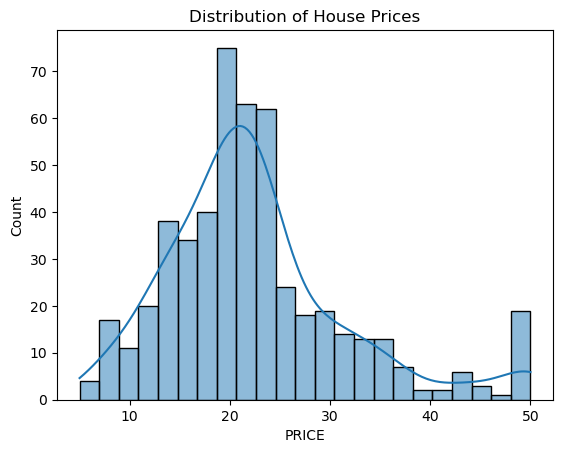

In [9]:
sns.histplot(df['PRICE'], kde=True)
plt.title("Distribution of House Prices")
plt.show()

### The distribution of house prices appears slightly right-skewed, indicating that while most houses fall within a moderate price range, there are some high-value properties that increase the overall average.

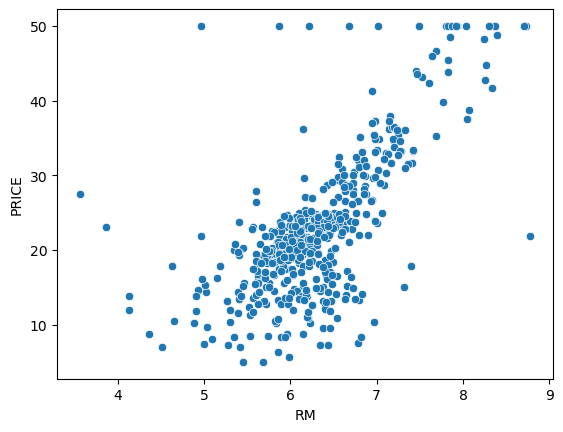

In [10]:
sns.scatterplot(x='RM', y='PRICE', data=df)
plt.show()

### There is a strong positive relationship between the number of rooms and house prices. Houses with more rooms tend to have significantly higher prices, making this one of the most influential features.

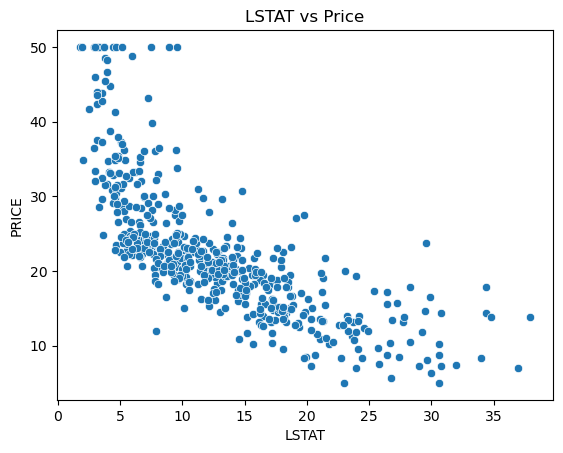

In [11]:
sns.scatterplot(x='LSTAT', y='PRICE', data=df)
plt.title("LSTAT vs Price")
plt.show()

### There is a clear negative relationship between LSTAT (percentage of lower-income population) and house prices. Areas with higher LSTAT values tend to have lower property prices.

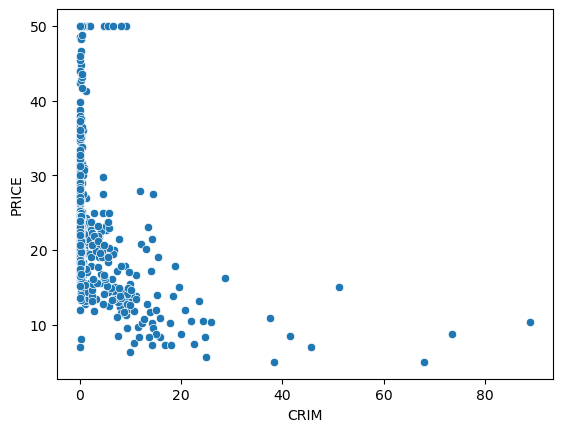

In [12]:
sns.scatterplot(x='CRIM', y='PRICE', data=df)
plt.show()

### Higher crime rates are generally associated with lower house prices, suggesting that safety plays a role in property valuation.

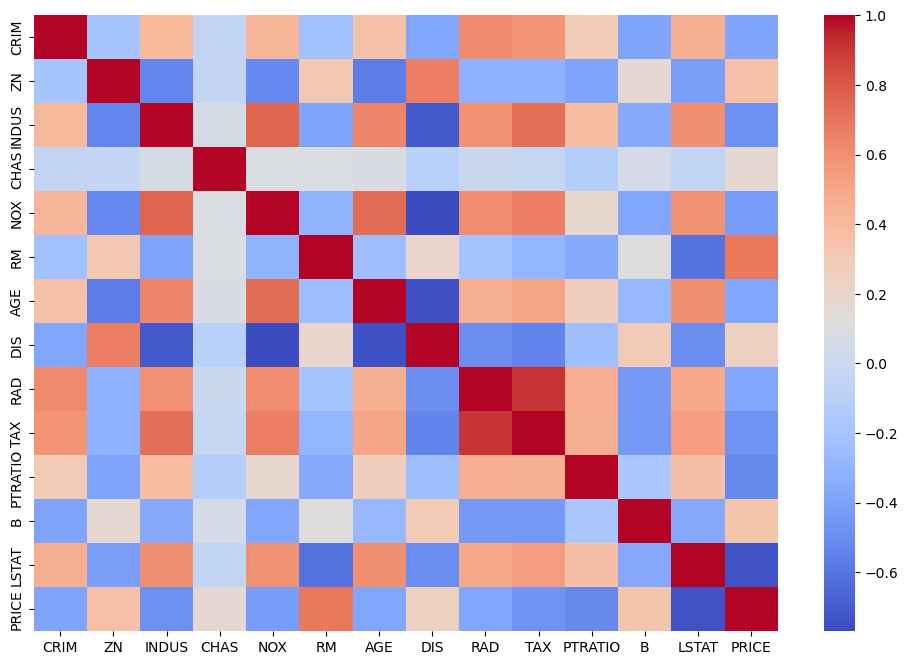

In [13]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

### Correlation analysis shows that RM has a strong positive relationship with price, while LSTAT has a strong negative relationship. These features are key drivers of housing prices in the dataset.

## Key Insights from EDA

#### The analysis reveals that the number of rooms (RM) is one of the strongest predictors of house prices, with larger homes commanding higher values.

#### In contrast, LSTAT, which represents the percentage of lower-income residents, shows a strong negative relationship with price, indicating that socioeconomic factors significantly influence housing values.

#### Additionally, higher crime rates are associated with lower property prices, suggesting that location and safety are important considerations for buyers.

#### Overall, the data highlights that both physical property features and environmental factors contribute to housing price variations.

## REGRESSION

## Define Features & Target

In [14]:
X = df.drop("PRICE", axis=1)
y = df["PRICE"]

## Train/Test Split

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Train Model

In [16]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## Make Predictions

In [17]:
y_pred = model.predict(X_test)


## Evaluate Model

In [18]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R²:", r2)

MSE: 19.379041116136854
R²: 0.6522201888666183


### The model explains a significant portion of the variance in house prices, indicating a good fit.

## Feature Importance

In [19]:
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=["Coefficient"])
coeff_df.sort_values(by="Coefficient", ascending=False)

,Coefficient
RM,4.088551
CHAS,2.487155
RAD,0.296234
ZN,0.035509
INDUS,0.020186
B,0.012065
AGE,0.008370
TAX,-0.011453
CRIM,-0.098642
LSTAT,-0.554132


### Features such as RM (number of rooms) have a strong positive impact on house prices, while LSTAT negatively affects pricing.

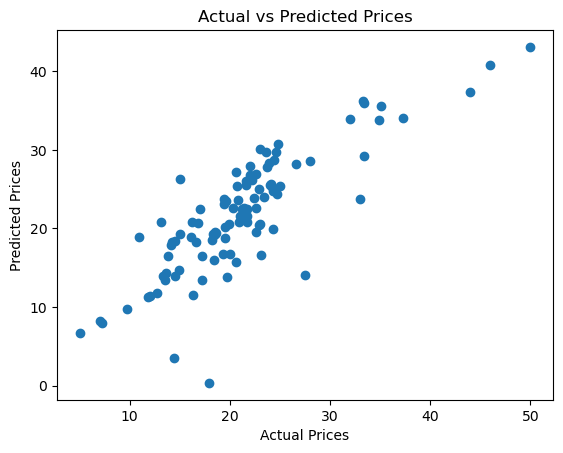

In [20]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

### The scatter plot shows how close the predicted values are to actual values. A tighter clustering along the diagonal line indicates better model performance.

## CLUSTERING

## Prepare Data

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

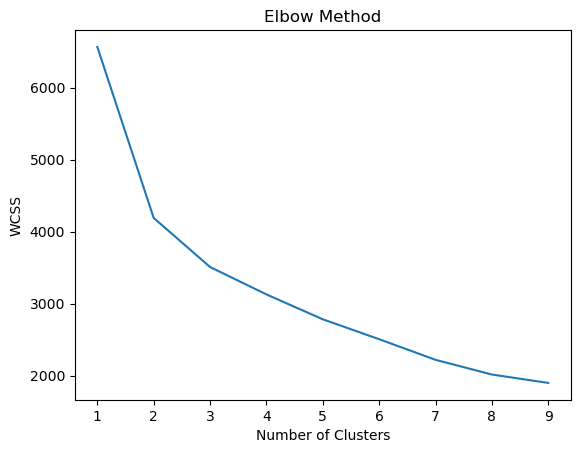

In [22]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 10), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [23]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

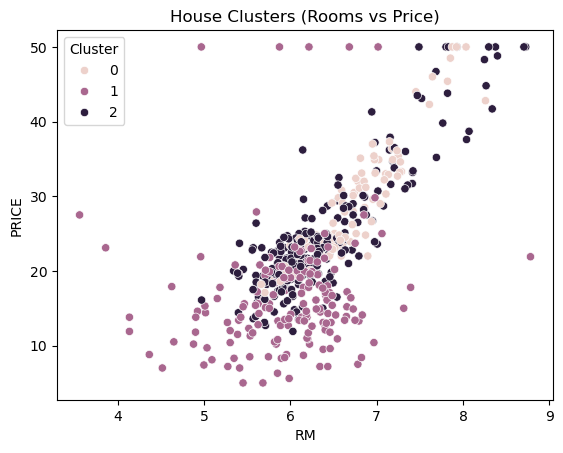

In [24]:
import seaborn as sns

sns.scatterplot(x='RM', y='PRICE', hue='Cluster', data=df)
plt.title("House Clusters (Rooms vs Price)")
plt.show()

In [25]:
df.groupby('Cluster').mean()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
Cluster,,,,,,,,,,,,,,
0,0.067479,52.521505,3.789677,0.053763,0.424115,6.712108,30.804301,6.855911,4.236559,302.537634,16.961290,389.289140,6.292258,28.888172
1,10.534719,0.000000,18.806585,0.073171,0.685104,5.958317,91.020122,1.996222,20.189024,626.560976,19.767073,298.178963,18.880000,16.240244
2,0.380916,3.417339,8.855565,0.072581,0.517492,6.338952,67.909677,3.835571,4.540323,303.951613,18.161290,382.963387,10.951492,24.304839


## Clustering Insights

### The clustering analysis grouped houses into three distinct segments:

### Cluster 0: Lower-priced houses with fewer rooms and higher LSTAT values
### Cluster 1: Mid-range houses with moderate features
### Cluster 2: High-value houses with more rooms and lower LSTAT values

### These clusters represent different segments of the housing market and highlight how both property features and socioeconomic factors influence housing value.


## Business Value

### Clustering helps identify different categories of houses, which can assist real estate investors, buyers, and sellers in making informed decisions based on market segmentation.

## CRIM → crime rate
## ZN → residential land
## RM → number of rooms
## LSTAT → % lower income population
## PRICE → house price (target)